In [42]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import numpy as np
from matplotlib.patches import Rectangle
import matplotlib.patches as mpatches
from utils_without_openai import compare_histograms, line_time_plot, stacked_time_plot

In [43]:
df = pd.read_pickle("../data/categorized/dataset_with_category.pkl")
df.head()

,title,publisher,date,section,body,length,letters_flag,country_flag,foreign_countries,us_mentions,source_file,publisher_raw,category
0,A Well-Documented Childhood. A Very Private Life.,New York Times,2024-12-31,Section A; Column 0; National Desk; Pg. 16,Jimmy Carter's daughter had an extraordinary a...,1209,False,BOTH,"[Egypt, Nicaragua, Mexico, Canada]","[Washington, Massachusetts, US, Rhode Island]",NYT/1.DOCX,The New York Times,US/National
1,These were the big stories in arts and culture...,Other publisher,2024-12-31,WHAT TO KNOW,The arts in Dayton continued to thrive in 2024...,3345,False,BOTH,"[Sierra Leone, Japan, France, United Kingdom]","[Georgia, New Jersey, America, USA, California...",Other publishers/Files (500) (1).DOCX,Dayton Daily News (Ohio),None
2,She Exalted The Beauty Of Dance,New York Times,2024-12-31,Section C; Column 0; The Arts/Cultural Desk; P...,She was The New Yorker's first dance critic. H...,1314,False,US_ONLY,[],"[US, North Carolina, United States, New York]",NYT/1.DOCX,The New York Times,Arts/Culture
3,"Under a Highway in Rio, a Dance Style Charms a...",New York Times,2024-12-31,WORLD; americas,"Trucks, buses and cars rumbled overhead, drown...",1333,False,BOTH,[Brazil],"[US, United States, New York]",NYT/1.DOCX,The New York Times,World/International
4,"Congressional pay, minimum wage stagnant for y...",Other publisher,2024-12-31,OPINION; Pg. A13,ABSTRACT\nMembers of Congress have not seen a ...,921,False,US_ONLY,[],"[New Jersey, Pennsylvania, America, Delaware, ...",Other publishers/Files (500) (1).DOCX,The Philadelphia Inquirer,Opinion/Editorial/Letters


In [44]:
def interactive_pie_charts(df, title="Category Distribution Comparison"):
    import plotly.graph_objects as go
    from plotly.subplots import make_subplots
    import plotly.express as px
    
    nyt_data = df[df['publisher'] == 'New York Times']['category'].value_counts()
    other_data = df[df['publisher'] != 'New York Times']['category'].value_counts()
    
    # Create subplots
    fig = make_subplots(
        rows=1, cols=2,
        specs=[[{"type": "pie"}, {"type": "pie"}]],
        subplot_titles=("NYT Category Distribution", "Other Publishers Category Distribution")
    )
    
    # NYT pie chart
    fig.add_trace(
        go.Pie(
            labels=nyt_data.index,
            values=nyt_data.values,
            name="NYT",
            hole=0.3,  # Makes it a donut chart
            textinfo='label+percent',
            textposition='outside',
            textfont=dict(size=12),
            hovertemplate='<b>%{label}</b><br>' +
                         'Count: %{value}<br>' +
                         'Percentage: %{percent}<br>' +
                         '<extra></extra>',
            showlegend=False
        ),
        row=1, col=1
    )
    
    # Other publishers pie chart
    fig.add_trace(
        go.Pie(
            labels=other_data.index,
            values=other_data.values,
            name="Others",
            hole=0.3,  # Makes it a donut chart
            textinfo='label+percent',
            textposition='outside',
            textfont=dict(size=12),
            hovertemplate='<b>%{label}</b><br>' +
                         'Count: %{value}<br>' +
                         'Percentage: %{percent}<br>' +
                         '<extra></extra>',
            showlegend=False
        ),
        row=1, col=2
    )
    
    # Update layout
    fig.update_layout(
        title=dict(
            text=title,
            x=0.5,
            font=dict(size=20, family="Arial Black")
        ),
        width=1200,
        height=600,
        font=dict(size=12),
        showlegend=False
    )
    
    fig.show()

# Usage:
interactive_pie_charts(df, "Interactive Category Distribution: NYT vs Others")

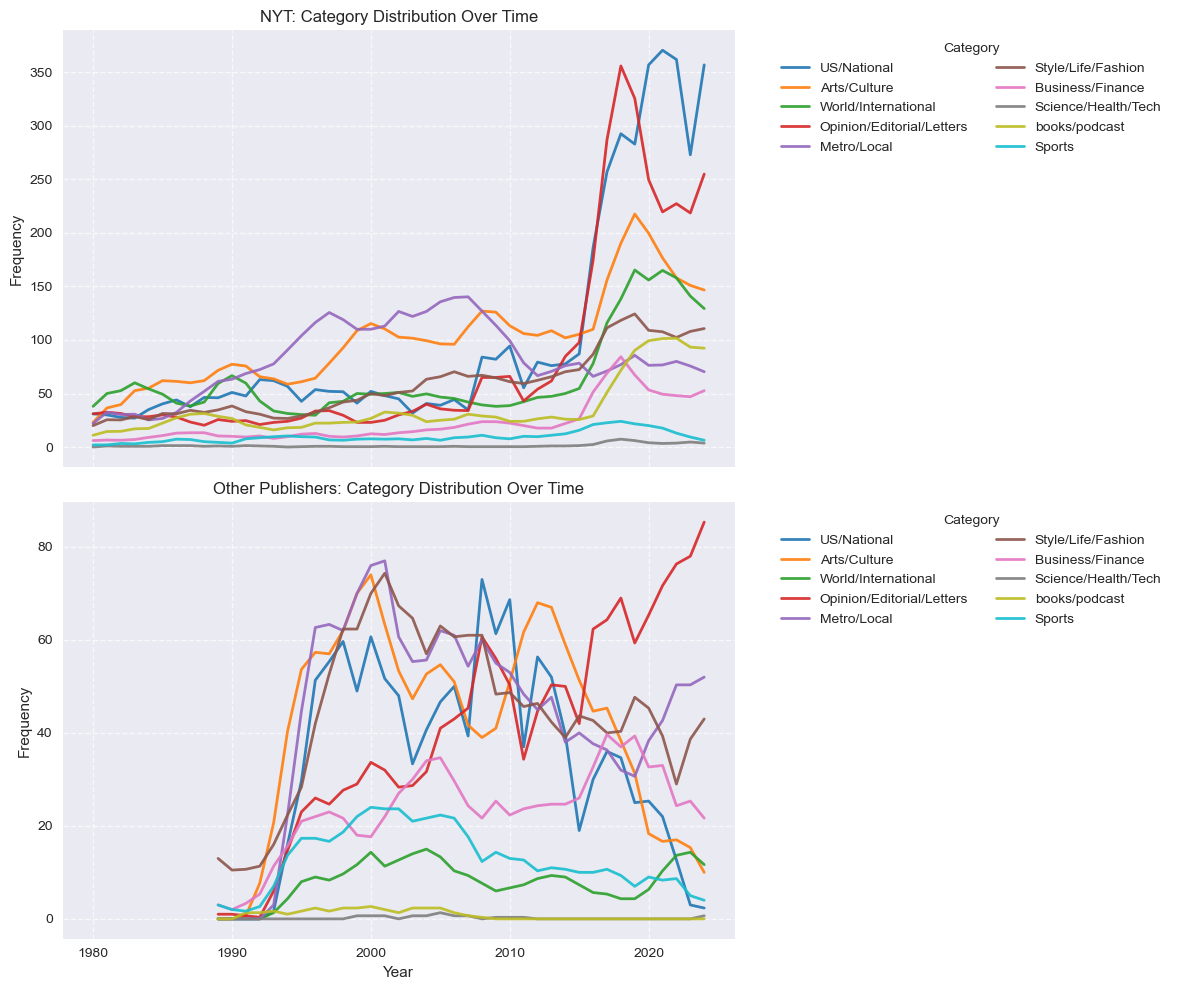

In [45]:
df['year'] = pd.to_datetime(df['date']).dt.year
nyt_mask = df['publisher'] == 'New York Times'
line_time_plot(
    df_articles_with_results=df,
    nyt_mask=nyt_mask,
    variable='category',
    title='Category Distribution Over Time',
    filename='category_distribution_over_time.png',
    variable_label='Category',
    smooth_window=3
)

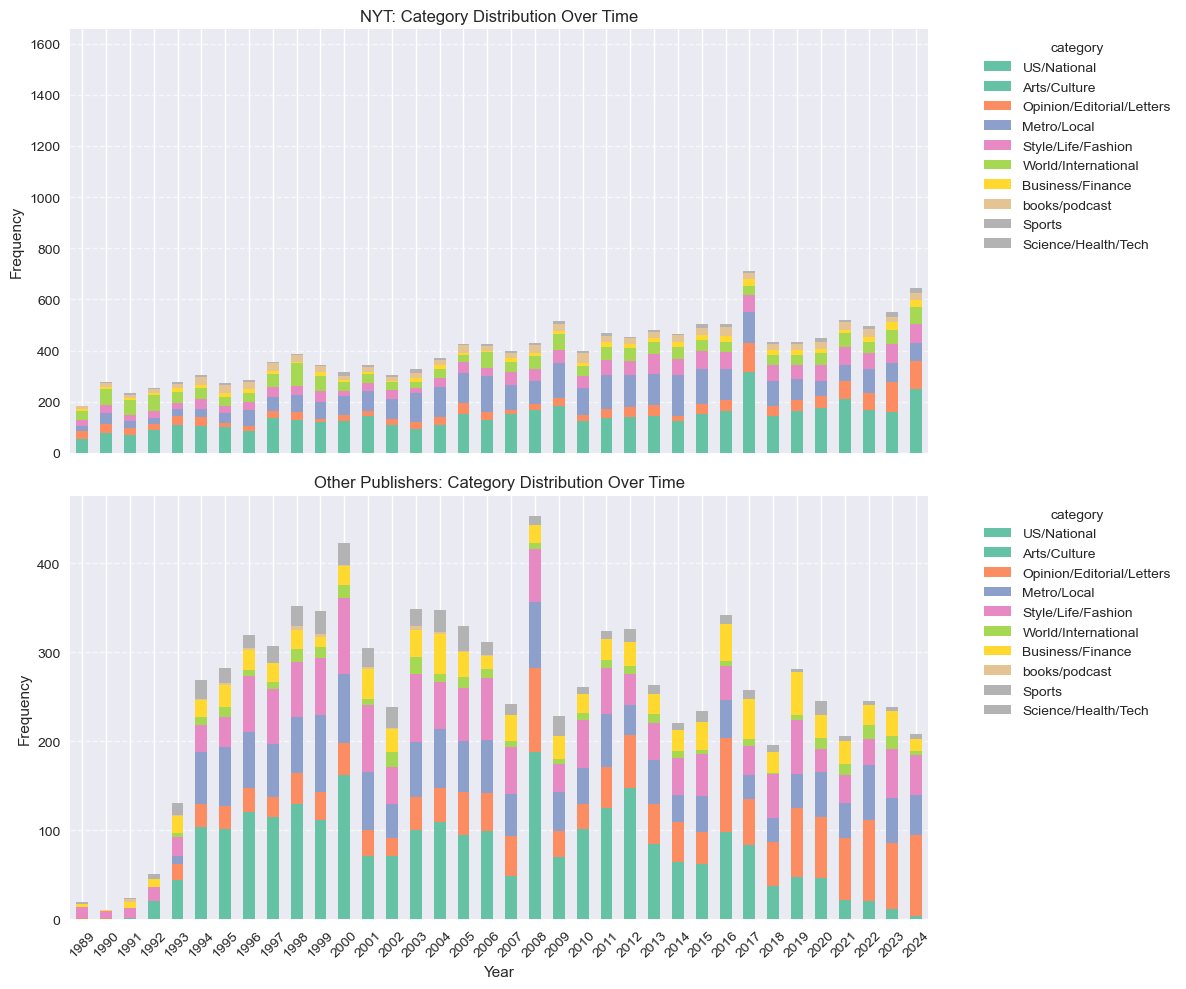

In [46]:
stacked_time_plot(
    df_articles_with_results=df,
    nyt_mask=nyt_mask,
    variable='category',
    title='Category Distribution Over Time'
)

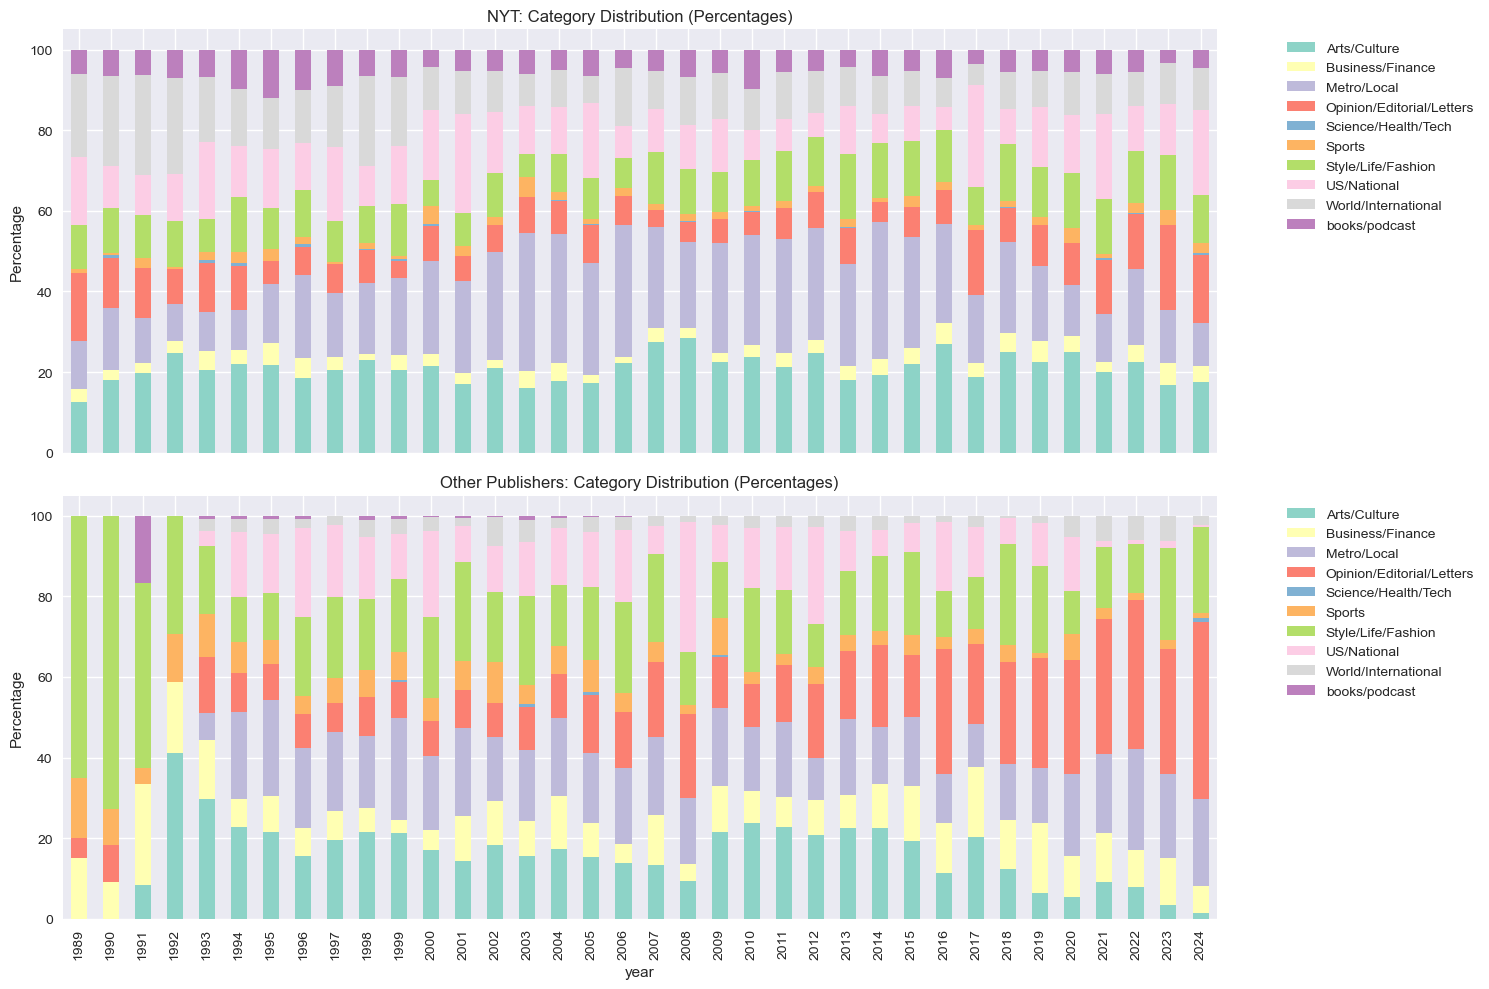

In [47]:
def proportional_stacked_plot(df, nyt_mask, variable, title):
    fig, axes = plt.subplots(2, 1, figsize=(15, 10), sharex=True)  # Made figure wider
    
    for ax, mask, subtitle in zip(axes, [nyt_mask, ~nyt_mask], 
                                 [f"NYT: {title}", f"Other Publishers: {title}"]):
        grouped = df[mask].groupby(["year", variable]).size().unstack(fill_value=0)
        grouped_pct = grouped.div(grouped.sum(axis=1), axis=0) * 100
        
        grouped_pct.plot(kind="bar", stacked=True, ax=ax)
        ax.set_ylabel("Percentage")
        ax.set_title(subtitle)
        
        # Move legend to the right side
        ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    
    plt.tight_layout()
    plt.show()

df['year'] = pd.to_datetime(df['date']).dt.year
nyt_mask = df['publisher'] == 'New York Times'
proportional_stacked_plot(df, nyt_mask, 'category', 'Category Distribution (Percentages)')

In [60]:
def get_random_row_by_category(df, category):
    """Get a random row for a specific category"""
    filtered_df = df[df['category'] == category]
    
    if filtered_df.empty:
        print(f"No rows found for category: '{category}'")
        return None
    
    return filtered_df.sample(n=1).iloc[0]

def display_row_info(row, category):
    """Display row information in a formatted way"""
    if row is None:
        return
    
    print(f"\nRANDOM ROW FROM CATEGORY: '{category}'")
    print("-" * 40)
    
    for column, value in row.items():
        print(f"{column}: {value}")
    print("-" * 40)

In [61]:
unique_categories = df['category'].unique()
print("Unique categories using .unique():")
print(unique_categories)

Unique categories using .unique():
['US/National' None 'Arts/Culture' 'World/International'
 'Opinion/Editorial/Letters' 'Metro/Local' 'Style/Life/Fashion'
 'Business/Finance' 'Science/Health/Tech' 'books/podcast' 'Sports']


In [62]:
target_category = "Style/Life/Fashion"

In [64]:
random_row = get_random_row_by_category(df, target_category)
display_row_info(random_row, target_category)


RANDOM ROW FROM CATEGORY: 'Style/Life/Fashion'
----------------------------------------
title: STAY TUNED IN TO WHAT SOOTHES YOU
publisher: Other publisher
date: 2001-11-18
section: LIFESTYLE,
body: In these trying times, we often turn to entertainment in the forms we each find to be most soothing for comfort. Here are some entertaining ways to kick back, relax and enjoy:
 Turn on the TV
 Although television largely is responsible for burning the images of Sept. 11 into our brains, it also can be a refuge. Sink into simpler times on TV Land, retreat to "Mister Rogers' Neighborhood" or be transported to Manhattan on Nov. 28 for NBC's "Christmas in Rockefeller Center" special that should be more special than usual.
 On Tuesday, a gentle fantasy called "Prancer Returns," written by Pittsburgh native Greg Taylor, will debut on cable's USA Network. On Thanksgiving morning, make a big breakfast and then gather around the set to watch the Macy's Thanksgiving Day Parade turn 75.
On Thanksgivi